In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


# Setup

In [2]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 94.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 90.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
dagshub_token = user_secrets.get_secret("DAGSHUB_TOKEN")

In [4]:
import dagshub
import mlflow
import mlflow.sklearn

dagshub.auth.add_app_token(token=dagshub_token)
dagshub.init(repo_owner='ngval22', repo_name='house_prices', mlflow=True)
mlflow.get_tracking_uri()

Accessing as ngval22

Initialized MLflow to track repo "ngval22/house_prices"

Repository ngval22/house_prices initialized!

'https://dagshub.com/ngval22/house_prices.mlflow'

# Data Analysis

In [5]:
df = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")


In [6]:
print(df.dtypes)
print('---------------------------------------------')
print(df.shape)

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object
---------------------------------------------
(1460, 81)


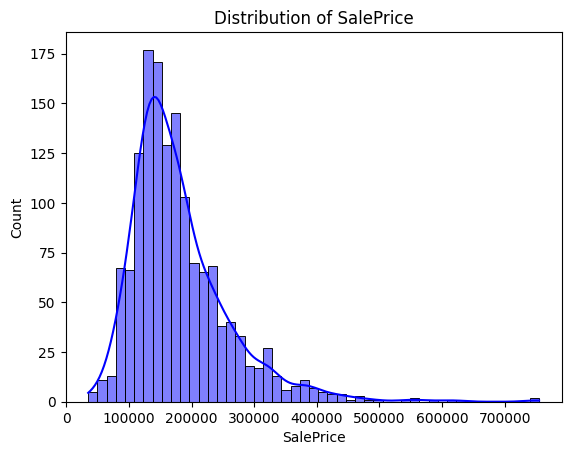

SalePrice mean is:  180921.19589041095


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['SalePrice'], kde=True, color='blue')
plt.title('Distribution of SalePrice')
plt.show()

print(f"SalePrice mean is: ", df['SalePrice'].mean())

In [8]:
from sklearn.model_selection import train_test_split

X=df.drop(columns=['SalePrice'])
y=df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
print(f"Train X: {X_train.shape}")
print(f"Train y: {y_train.shape}")
print(f"Test X:  {X_test.shape}")
print(f"Test y:  {y_test.shape}")

Train X: (1168, 80)
Train y: (1168,)
Test X:  (292, 80)
Test y:  (292,)


In [10]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    951 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          74 non-null     object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64  
 18  OverallCond

In [11]:
X_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1168.000000,1168.000000,951.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1162.000000,1168.000000,...,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000
mean,730.904966,56.849315,70.343849,10689.642123,6.121575,5.584760,1970.965753,1984.897260,103.771945,446.023973,...,476.273973,95.946918,49.578767,21.839041,3.812500,15.407534,2.955479,51.267123,6.356164,2007.818493
std,425.369088,42.531862,24.897021,10759.366198,1.367619,1.116062,30.675495,20.733955,173.032238,459.070977,...,211.095373,129.685939,69.433580,62.083227,31.519664,55.881148,41.648504,553.039684,2.670707,1.322639
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,360.750000,20.000000,59.000000,7587.250000,5.000000,5.000000,1953.000000,1966.000000,0.000000,0.000000,...,341.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000
50%,732.500000,50.000000,70.000000,9600.000000,6.000000,5.000000,1972.000000,1994.000000,0.000000,384.500000,...,482.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,1101.750000,70.000000,80.000000,11700.000000,7.000000,6.000000,2001.000000,2004.000000,166.000000,721.000000,...,576.000000,168.000000,74.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1378.000000,5644.000000,...,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000


In [12]:
na_percentages = X_train.isna().mean()

In [13]:
top_na_columns=na_percentages[na_percentages > 0].sort_values(ascending=False)
top_na_columns

PoolQC          0.994863
MiscFeature     0.960616
Alley           0.936644
Fence           0.800514
MasVnrType      0.584760
FireplaceQu     0.468322
LotFrontage     0.185788
GarageType      0.054795
GarageYrBlt     0.054795
GarageFinish    0.054795
GarageQual      0.054795
GarageCond      0.054795
BsmtCond        0.023973
BsmtFinType1    0.023973
BsmtExposure    0.023973
BsmtQual        0.023973
BsmtFinType2    0.023973
MasVnrArea      0.005137
Electrical      0.000856
dtype: float64

**აქედან შეგვიძლია დავასკვნათ რომ Bsmt... რადგან ერთნაირი nan პროცენტულობა აქვს, სავარაუდოდ ნიშნავს რომ უბრალოდ სარდაფი არ აქვს შესაბამის საცხოვრებელს, იგივე შეიძლება ითქვას გარაჟზე, Fence, Alley, PoolQC სვეტებიც სავარაუდოდ ღობის, აუზის არსებობა არარსებობაზეა და არა იმაზე რომ მონაცემი ვერ მოიძებნა, ამ სვეტების დადროპვა არ იქნება გონივრული რადგან მნიშვნელოვნად კორელირებს ფასთან**

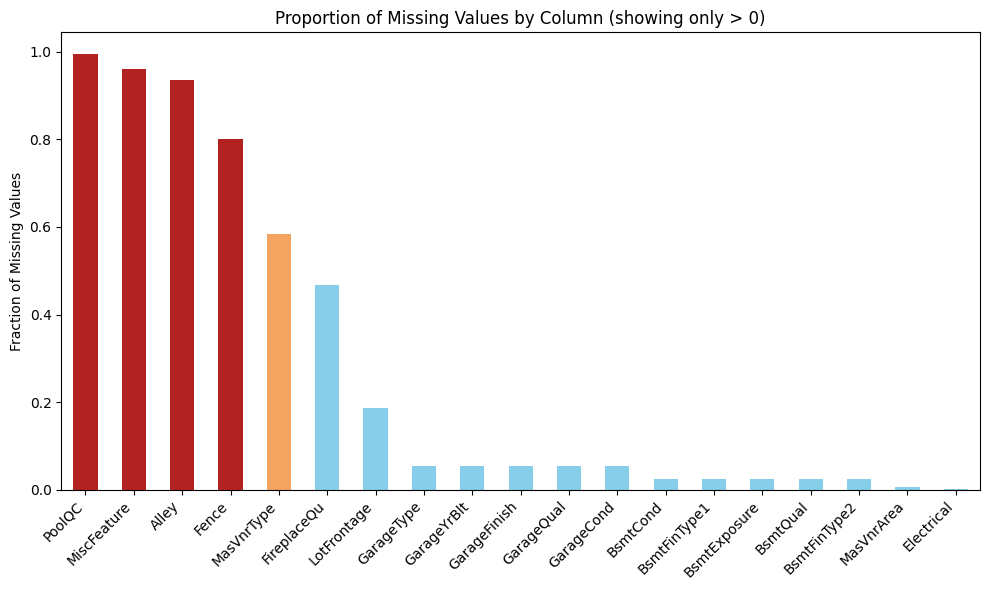

In [14]:
import matplotlib.pyplot as plt

colors = [
    'firebrick' if val > 0.7 else 'sandybrown' if val > 0.5 else 'skyblue' 
    for val in top_na_columns
]
plt.figure(figsize=(10, 6))
top_na_columns.plot(kind='bar', color=colors)
plt.title('Proportion of Missing Values by Column (showing only > 0)')
plt.ylabel('Fraction of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [15]:
categorical_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
numerical_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']

print(f"Categorical ({len(categorical_cols)}): \n {categorical_cols} \n")
print(f"Numerical ({len(numerical_cols)}): \n {numerical_cols}")

Categorical (43): 
 ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'] 

Numerical (37): 
 ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'Gar

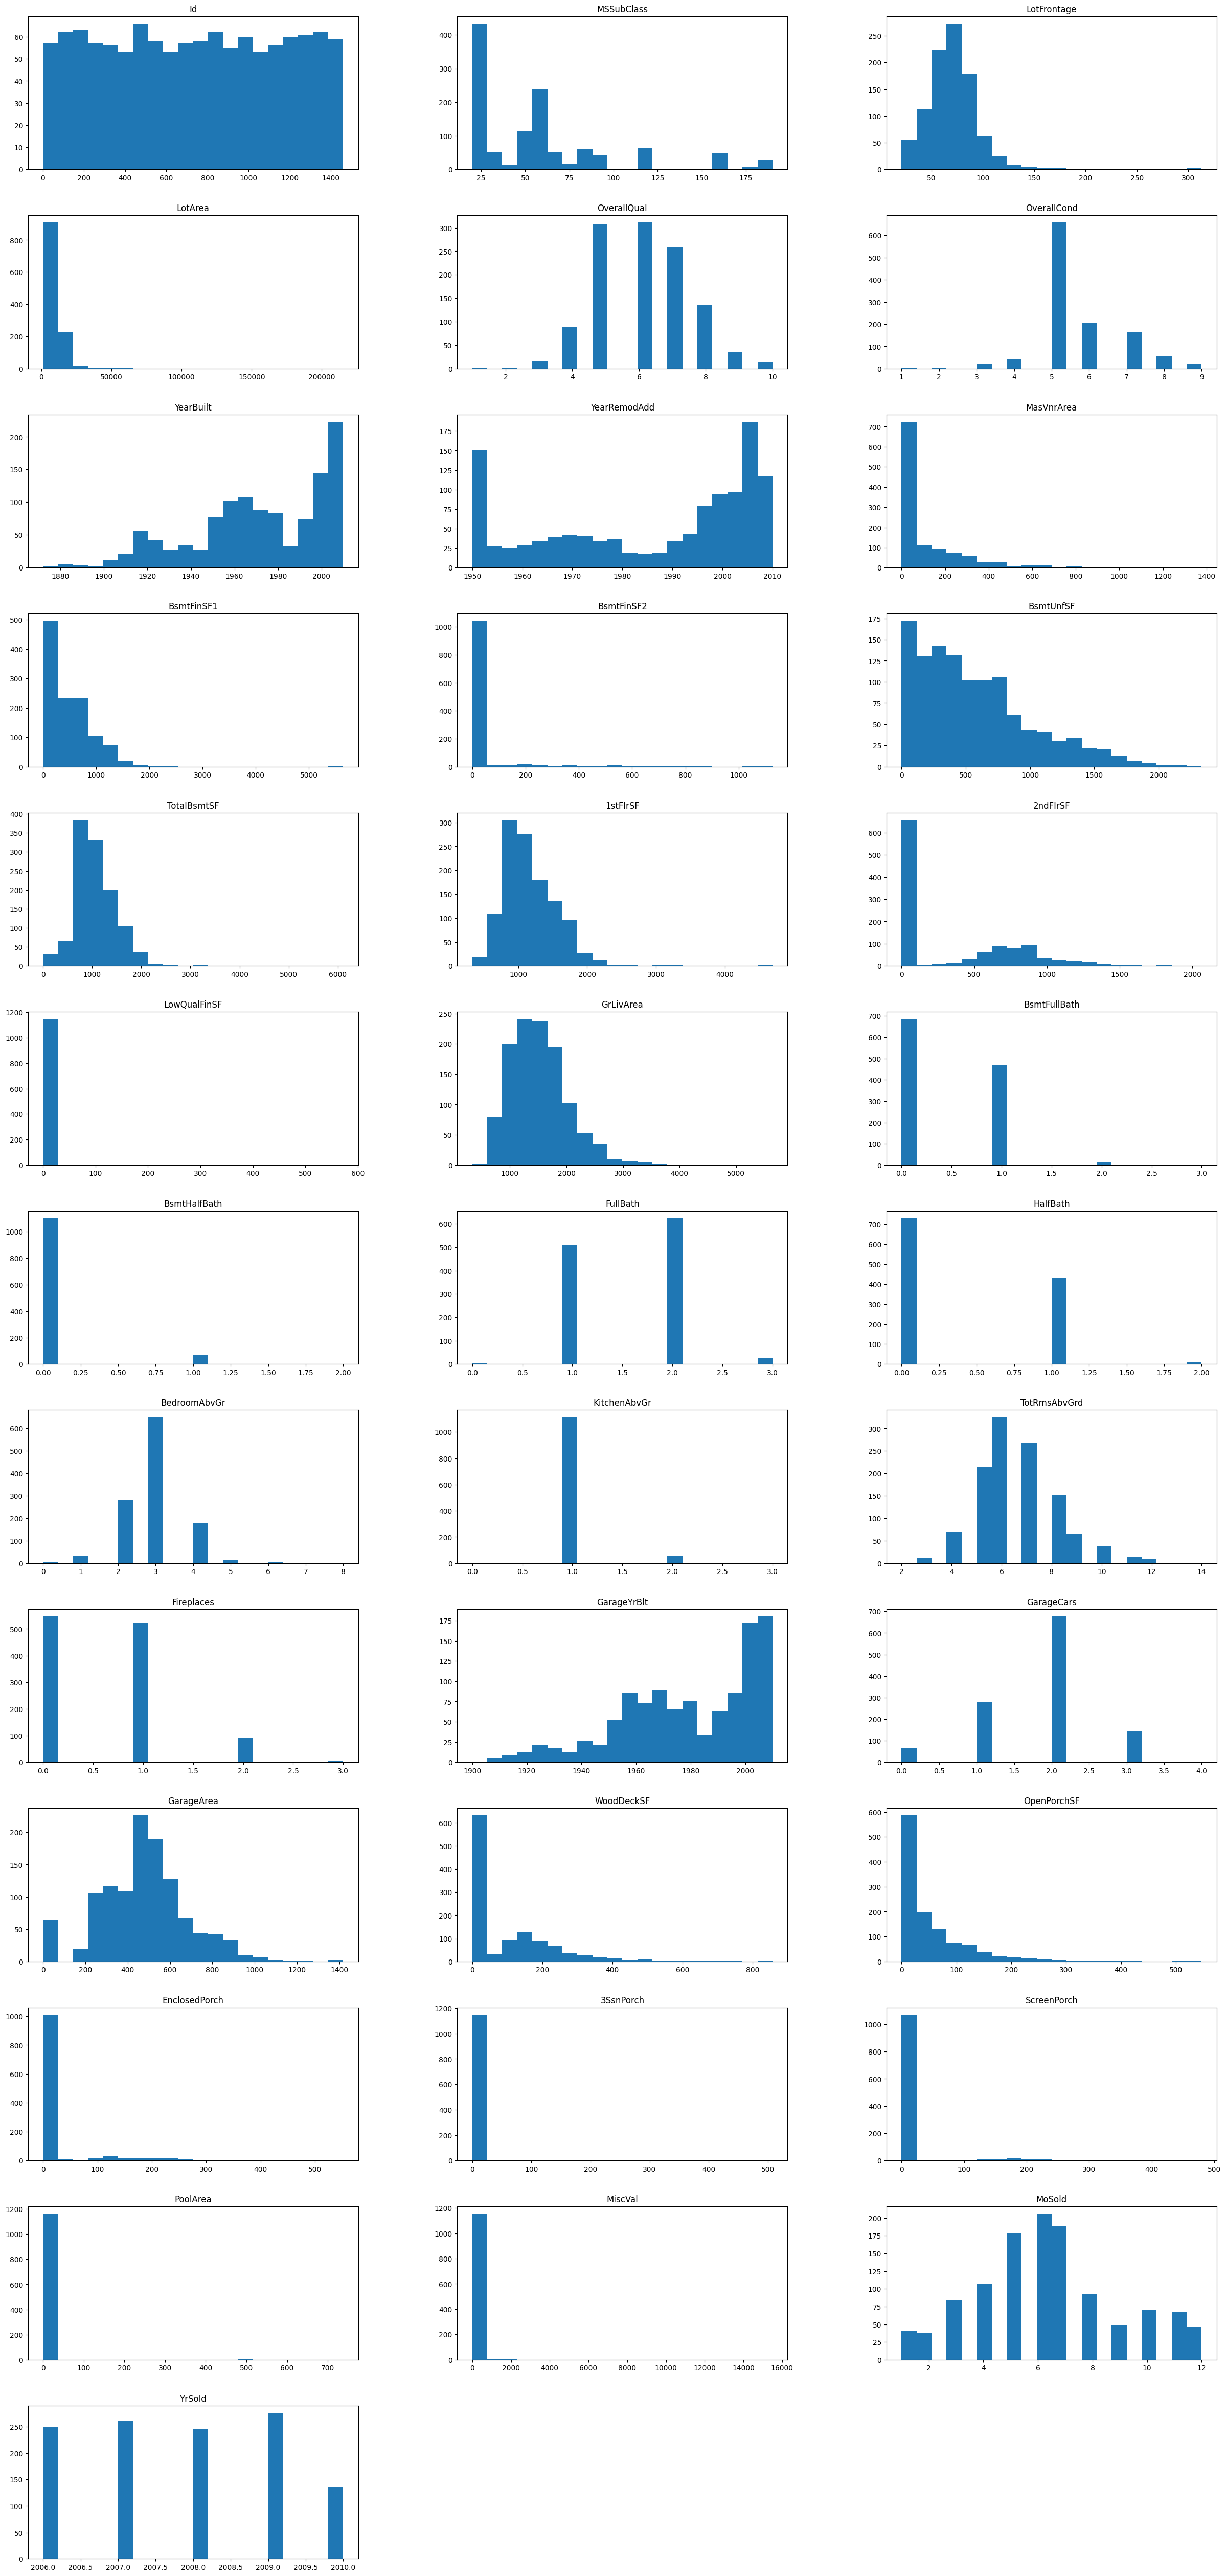

In [16]:
import matplotlib.pyplot as plt

X_train[numerical_cols].hist(
    bins=20, 
    figsize=(30, 100),
    layout=(20, 3),    
    grid=False         
)

plt.show()

In [17]:
train_corr = X_train[numerical_cols].join(y_train).corr()
# top_features = train_corr['SalePrice'].sort_values(ascending=False).index

top_features = train_corr['SalePrice'].abs().sort_values(ascending=False)

top_features

SalePrice        1.000000
OverallQual      0.785555
GrLivArea        0.695652
GarageCars       0.640991
GarageArea       0.624139
TotalBsmtSF      0.597766
1stFlrSF         0.587883
FullBath         0.552546
TotRmsAbvGrd     0.520388
YearBuilt        0.516501
YearRemodAdd     0.508593
GarageYrBlt      0.480351
MasVnrArea       0.459123
Fireplaces       0.457549
BsmtFinSF1       0.359460
LotFrontage      0.330066
WoodDeckSF       0.329843
2ndFlrSF         0.314030
OpenPorchSF      0.299969
HalfBath         0.280481
LotArea          0.266204
BsmtFullBath     0.226346
BsmtUnfSF        0.222487
BedroomAbvGr     0.156211
EnclosedPorch    0.149532
KitchenAbvGr     0.142785
ScreenPorch      0.119172
PoolArea         0.115630
MSSubClass       0.088081
OverallCond      0.074391
3SsnPorch        0.051532
BsmtHalfBath     0.048346
MoSold           0.041890
MiscVal          0.020179
Id               0.019643
LowQualFinSF     0.011189
YrSold           0.009099
BsmtFinSF2       0.005731
Name: SalePr

In [18]:

weak_features = train_corr.index[abs(train_corr['SalePrice']) <= 0.05]

print(f"weak features:\n", len(weak_features), weak_features)


weak features:
 7 Index(['Id', 'BsmtFinSF2', 'LowQualFinSF', 'BsmtHalfBath', 'MiscVal', 'MoSold',
       'YrSold'],
      dtype='object')


**target-თან სუსტი კორელაციის გამო ამ სვეტებს დავდროპავ**

In [92]:
X_train['SaleType'].isna().mean()

np.float64(0.0)

# Cleaning

In [24]:
drop_cols = ['Id', 'BsmtFinSF2', 'LowQualFinSF', 'BsmtHalfBath', 
                'MiscVal', 'MoSold','YrSold', 'GarageYrBlt', 'MiscFeature']

zero_fill_cols = [
    
]

special_col = ['SaleCondition']

mode_fill_cols = [
     'MasVnrArea', 'LotFrontage',
]

# fill with frequent and ohe
fill_with_frequent_categorical = [
    'Electrical', 'BsmtFinType1', 'BsmtFinType2', 'GarageType', 'MasVnrType',
]

# needs filling with none and one hot encoding
fill_with_none_ohe = [
    'Alley', 'Fence',
    'GarageType',
    'MasVnrType',
]

# needs filling with none and ordered encoding, different types
ordered_enc_cols = [
    'PoolQC', 
    'BsmtQual', 'BsmtExposure', 'BsmtCond', 
    'GarageQual', 'GarageCond', 'GarageFinish',
    'FireplaceQu', 
]

# fully filled but needs one hot encoding
ohe_ready_cols = [
    'MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 
    'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
    'OverallQual', 'OverallCond', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
    'Foundation', 'Heating', 'CentralAir', 'Functional', 'PavedDrive', 'SaleType', 'SaleCondition',
]

# fully filled but needs ordered encoding
ordered_enc_ready_cols = [
    'ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual',
]

# Feature Engineering

# Feature Selection

# Training